(44898, 6)


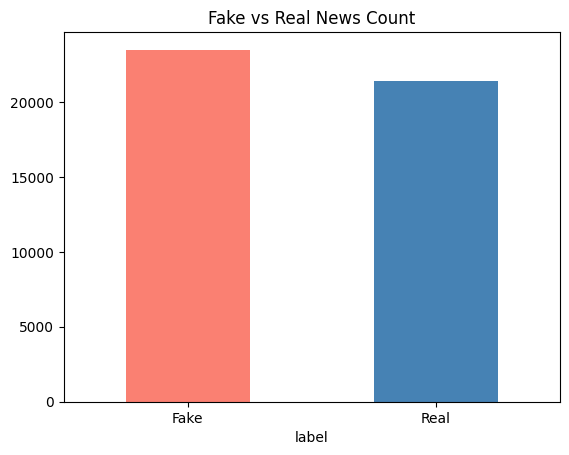

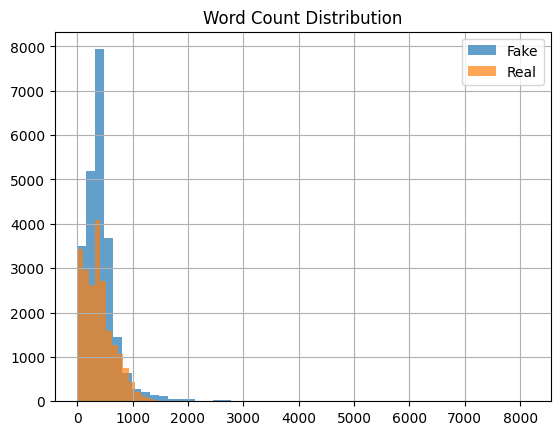

Shape: (35918, 10000)
Naive Bayes Accuracy: 0.9436525612472161
Logistic Regression Accuracy: 0.9867483296213808
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4710
        Real       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



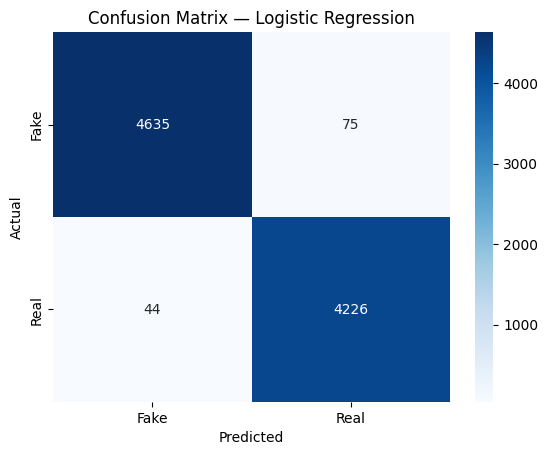

Prediction: 🚨 FAKE
Confidence: 82.75%
Prediction: 🚨 FAKE
Confidence: 97.85%


In [8]:
# Fake News Detection using ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load & Prepare Dataset
fake = pd.read_csv("/content/drive/MyDrive/projects for resume/Fake.csv")
true = pd.read_csv("/content/drive/MyDrive/projects for resume/True.csv")

# Adds labels
fake["label"] = 0   # 0 = FAKE
true["label"] = 1   # 1 = REAL

# Combine
df = pd.concat([fake, true], ignore_index=True)

# Use title + text combined for better accuracy
df["content"] = df["title"] + " " + df["text"]

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

# Explore the Data (EDA)

# Class distribution
df["label"].value_counts().plot(kind="bar", color=["salmon", "steelblue"])
plt.xticks([0, 1], ["Fake", "Real"], rotation=0)
plt.title("Fake vs Real News Count")
plt.show()

# Article length distribution
df["word_count"] = df["content"].apply(lambda x: len(str(x).split()))
df.groupby("label")["word_count"].hist(alpha=0.7, bins=50)
plt.legend(["Fake", "Real"])
plt.title("Word Count Distribution")
plt.show()

# Text Preprocessing
import re
import string

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'\[.*?\]', '', text)               # remove brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>+', '', text)                # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\n', ' ', text)                   # remove newlines
    text = re.sub(r'\w*\d\w*', '', text)              # remove words with numbers
    return text

df["content_clean"] = df["content"].apply(clean_text)

# TF-IDF Vectorization
X = df["content_clean"]
y = df["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF: converts text → numeric features
tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Shape:", X_train_tfidf.shape)

# Train Models

# Model 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

# Model 2: Logistic Regression (add this for resume impact!)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))

# Evaluate & Visualize

# Classification report
print(classification_report(y_test, lr_preds, target_names=["Fake", "Real"]))

# Confusion matrix
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# Live Prediction Function
def predict_news(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr.predict(vectorized)[0]
    probability = lr.predict_proba(vectorized)[0]

    label = "✅ REAL" if prediction == 1 else "🚨 FAKE"
    confidence = max(probability) * 100

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")

# Test it!
predict_news("""
Scientists at NASA have confirmed the discovery of water ice
beneath the surface of Mars using the Mars Reconnaissance Orbiter.
The findings were published in the journal Science and verified
by independent researchers across three universities.
""")
predict_news("Obama caught secretly meeting with aliens in Area 51")